Builds isolated trees to separate anomalies

### how the isolation forest works

1. random selection 
2. tree building
3. isolation path
4. anomaly score

### key characteristics 
1. works well for high dimensional data
2. speed = O(n log n) time complexity, very efficient
3. doesnt rely on distance calculation, so no distance metrics
4. scalability = handle large dataset well
5. minimal hyperparameters to tune

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

In [3]:
# Generate sample data with anomalies
X, _ = make_blobs(n_samples=300, centers=1, n_features=2, random_state=42)
# Add some anomalies
anomalies = np.random.uniform(low=-8, high=8, size=(20, 2))
X = np.vstack([X, anomalies])

In [4]:
# Create and fit Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,  # Expected proportion of anomalies
    random_state=42,
    n_estimators=100
)

In [5]:
# Predict anomalies (-1 for anomalies, 1 for normal)
predictions = iso_forest.fit_predict(X)

# Get anomaly scores (lower = more anomalous)
scores = iso_forest.score_samples(X)

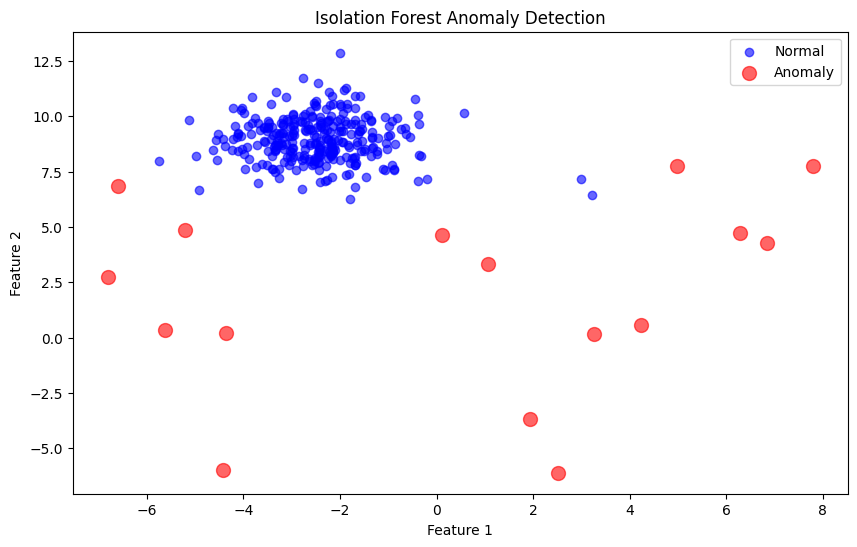

In [6]:
# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X[predictions == 1, 0], X[predictions == 1, 1], 
           c='blue', label='Normal', alpha=0.6)
plt.scatter(X[predictions == -1, 0], X[predictions == -1, 1], 
           c='red', label='Anomaly', alpha=0.6, s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Isolation Forest Anomaly Detection')
plt.legend()
plt.show()

In [7]:
# Real-world example with features
print("Number of anomalies detected:", (predictions == -1).sum())
print("Anomaly scores (sample):", scores[:5])

Number of anomalies detected: 16
Anomaly scores (sample): [-0.35126636 -0.37904435 -0.44266834 -0.3567124  -0.49197054]
